## <span style="color: #29fe6c">Atelier Préparation des Données </span>

## <span style="color: #51c977">Contexte</span>  
Une entreprise exploite plusieurs bâtiments intelligents équipés de capteurs IoT.
Chaque capteur 
collecte régulièrement des informations sur la température, l'humidité, la qualité de l'air, la 
consommation énergétique, le nombre de personnes présentes, le type de bâtiment, le mode de 
fonctionnement et l'état du système de climatisation. 
Les données collectées sont destinées à alimenter ultérieurement un modèle de Machine Learning 
capable de prédire la consommation énergétique ou de détecter les situations anormales. 

Cependant, les données brutes présentent volontairement différents problèmes : valeurs 
manquantes, doublons, valeurs aberrantes, types incorrects, valeurs incohérentes, variables 
catégorielles, catégories rares, déséquilibre des classes et échelles différentes entre variables. 
L'objectif de l'atelier est donc de transformer le fichier brut en un jeu de données propre et prêt 
pour le Machine Learning. 

In [296]:
# Importation de librairie
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### <span style="color: #2982fe">Partie 1 – Exploration des données </span>

##### <span style="color: #8eb9f6">1) Chargement des données CSV </span>

In [297]:
df = pd.read_csv("../data/smart_building_raw.csv")

##### <span style="color: #8eb9f6">2) Affichage des premières lignes du dataset</span>

In [298]:
df.head()

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
0,1174,2025-02-13 06:00:00,B8,Entrepôt,A,23.0,40.0,851.0,26.0,138.4,Eco,Normal,Jeudi,Non
1,1275,2025-03-10 12:00:00,B7,Bureau,D,28.0,69.0,538.0,0.0,170.2,Eco,Normal,Lundi,Non
2,1493,2025-05-04 00:00:00,B5,Centre commercial,B,19.5,52.3,1198.0,64.0,149.8,Normal,Normal,Dimanche,Oui
3,1073,2025-01-19 00:00:00,B6,Université,D,20.0,58.4,1014.0,30.0,141.6,Normal,Normal,Dimanche,Non
4,1454,2025-04-24 06:00:00,B7,Bureau,D,26.8,70.5,628.0,42.0,228.3,Normal,Normal,Jeudi,Non


In [299]:
df.shape

(507, 14)

##### <span style="color: #8eb9f6">3) Affichage des dernières lignes du dataset </span>

In [300]:
df.tail()

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
502,1107,2025-01-27 12:00:00,B2,École,C,29.8,66.5,778.0,48.0,243.5,Normal,Normal,Lundi,Non
503,1271,2025-03-09 12:00:00,B3,Hôpital,B,21.1,66.3,3900.0,53.0,145.8,Eco,Alerte,Dimanche,Oui
504,1349,2025-03-29 00:00:00,B5,Centre commercial,B,21.6,61.9,959.0,33.0,100.2,Eco,Normal,Samedi,Non
505,1436,2025-04-19 18:00:00,B7,Bureau,C,21.2,54.5,1066.0,38.0,150.9,Boost,Normal,Samedi,Oui
506,1103,2025-01-26 12:00:00,B2,École,D,NaN,64.8,584.0,29.0,163.4,Normal,Panne,Dimanche,Non


##### <span style="color: #8eb9f6">4) Nombre d'observations du dataset</span>

In [301]:
print("Nombre de données d'observation : ", df.shape[0])

Nombre de données d'observation :  507


##### <span style="color: #8eb9f6">5) Nombres de variables du dataset</span>

In [302]:
print("Nombre de variables : ", df.shape[1])
print("Nom des variables : ", df.columns.tolist())

Nombre de variables :  14
Nom des variables :  ['id_mesure', 'date', 'batiment', 'type_batiment', 'zone', 'temperature', 'humidite', 'co2', 'occupation', 'consommation_kwh', 'mode_climatisation', 'etat_systeme', 'jour_semaine', 'alerte']


##### <span style="color: #8eb9f6">6) Identifification des variables numériques</span> 

In [303]:
print("Variables de type numérique : ", df.select_dtypes(include=np.number).columns.tolist())

Variables de type numérique :  ['id_mesure', 'temperature', 'humidite', 'co2', 'occupation', 'consommation_kwh']


##### <span style="color: #8eb9f6">7) Identifification des variables catégorielles</span> 

In [304]:
print('Variables de type catégoriel : ', df.select_dtypes(include='object').columns.tolist())

Variables de type catégoriel :  ['date', 'batiment', 'type_batiment', 'zone', 'mode_climatisation', 'etat_systeme', 'jour_semaine', 'alerte']


##### <span style="color: #8eb9f6">8) Identification des dates</span>

In [305]:
print("Variables date \n: ", df.date)
print("type de la variable date : ", type(df.date[0]))

Variables date 
:  0      2025-02-13 06:00:00
1      2025-03-10 12:00:00
2      2025-05-04 00:00:00
3      2025-01-19 00:00:00
4      2025-04-24 06:00:00
              ...         
502    2025-01-27 12:00:00
503    2025-03-09 12:00:00
504    2025-03-29 00:00:00
505    2025-04-19 18:00:00
506    2025-01-26 12:00:00
Name: date, Length: 507, dtype: object
type de la variable date :  <class 'str'>


##### <span style="color: #8eb9f6">9) Identification des identifiants</span>

In [306]:
print("Les identifiants \n", df.id_mesure)
print("type de la variable id_mesure : ", type(df.id_mesure[0]))
print("Le nombre de identifiants uniques : ", df.id_mesure.nunique())

Les identifiants 
 0      1174
1      1275
2      1493
3      1073
4      1454
       ... 
502    1107
503    1271
504    1349
505    1436
506    1103
Name: id_mesure, Length: 507, dtype: int64
type de la variable id_mesure :  <class 'numpy.int64'>
Le nombre de identifiants uniques :  500


##### <span style="color: #8eb9f6">Informations globales du jeu de données</span>

In [307]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 507 entries, 0 to 506
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_mesure           507 non-null    int64  
 1   date                507 non-null    object 
 2   batiment            507 non-null    object 
 3   type_batiment       503 non-null    object 
 4   zone                507 non-null    object 
 5   temperature         495 non-null    float64
 6   humidite            496 non-null    float64
 7   co2                 500 non-null    float64
 8   occupation          501 non-null    float64
 9   consommation_kwh    502 non-null    float64
 10  mode_climatisation  502 non-null    object 
 11  etat_systeme        507 non-null    object 
 12  jour_semaine        502 non-null    object 
 13  alerte              507 non-null    object 
dtypes: float64(5), int64(1), object(8)
memory usage: 55.6+ KB


##### <span style="color: #8eb9f6">10) Déterminons les statistiques descriptives</span> 

In [308]:
# Statistiques descriptives des variables numériques
df.describe()

,id_mesure,temperature,humidite,co2,occupation,consommation_kwh
count,507.000000,495.000000,496.000000,500.000000,501.000000,502.000000
mean,1251.114398,24.154141,57.864113,844.150000,44.850299,169.069323
std,144.782769,7.418465,16.026336,582.181386,24.949139,53.164294
min,1001.000000,-30.000000,-12.000000,89.000000,-20.000000,-100.000000
25%,1125.500000,21.600000,49.275000,623.750000,27.000000,136.875000
50%,1252.000000,24.000000,57.550000,787.500000,46.000000,169.800000
75%,1376.500000,26.000000,65.750000,952.000000,61.000000,202.975000
max,1500.000000,96.000000,160.000000,6000.000000,116.000000,336.200000


In [309]:
# Statistiques descriptives des variables catégorielles
df.describe(include='object')

,date,batiment,type_batiment,zone,mode_climatisation,etat_systeme,jour_semaine,alerte
count,507,507,503,507,502,507,502,507
unique,500,8,16,4,7,3,7,2
top,2025-04-11 06:00:00,B1,Bureau,B,Normal,Normal,Vendredi,Non
freq,2,94,210,143,271,442,75,361


##### <span style="color: #8eb9f6">11)Variables potentiellement problématiques </span> 

In [310]:
print("type de la variable date : ", type(df.date[0]))

type de la variable date :  <class 'str'>


__Note__ : 
On constate que la variable 'date' est de type 'object' : catégorielle c'est problématique

In [311]:
# Conversion de la colonne 'date' en format datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

##### <span style="color: #8eb9f6">12) Pour les données incohérentes</span>
a) recherche des valeurs telles que humidité < 0 

In [312]:
# recherche des valeurs telles que humidité < 0
df[df.humidite < 0]

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
281,1126,2025-02-01 06:00:00,B2,École,D,24.8,-5.0,759.0,57.0,225.2,Boost,Normal,Samedi,Non
335,1036,2025-01-09 18:00:00,B4,Bureau,D,21.2,-8.0,160.0,25.0,120.2,Normal,Alerte,Jeudi,Non
366,1216,2025-02-23 18:00:00,B3,Hôpital,B,23.2,-12.0,702.0,41.0,119.8,Normal,Normal,Dimanche,Non


__Note__ : Il y'a trois dates dont la valeur de l'humidité est inférieur à 0

b) recherche des valeurs telles que humidité > 100

In [313]:
# valeurs telles que humidité > 100
df[df.humidite > 100]

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
59,1246,2025-03-03 06:00:00,B5,Centre commercial,A,24.2,108.0,813.0,18.0,-15.0,Normal,Normal,Lundi,Non
103,1016,2025-01-04 18:00:00,B6,Université,B,26.9,145.0,670.0,28.0,175.9,Normal,Normal,Samedi,Non
128,1156,2025-02-08 18:00:00,B1,Bureau,A,NaN,160.0,941.0,37.0,149.8,Eco,Normal,Samedi,Oui
160,1186,2025-02-16 06:00:00,B8,Entrepôt,B,24.9,125.0,NaN,18.0,123.5,Normal,Normal,Dimanche,Non
268,1276,2025-03-10 18:00:00,B1,Bureau,D,26.0,140.0,633.0,25.0,148.3,Normal,Normal,Lundi,Non
327,1066,2025-01-17 06:00:00,B2,École,C,25.8,132.0,646.0,14.0,93.6,Eco,Normal,Vendredi,Non
342,1096,2025-01-24 18:00:00,B8,Entrepôt,A,20.3,110.0,783.0,55.0,121.0,Normal,Normal,Vendredi,Non


__Note__ : Il y'a sept dates dont la valeur de l'humidité est supérieur à 100

c) recherche des valeurs telles que température extrêmement élevée 

In [314]:
# valeurs telles que température extrêmement élevée
df[df.temperature > 60]

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
7,1141,2025-02-05,B2,École,D,72.5,78.3,257.0,100.0,239.7,Boost,Alerte,Mercredi,Non
116,1181,2025-02-15,B6,Université,A,96.0,86.5,874.0,115.0,241.5,Normal,Normal,Samedi,Non
161,1061,2025-01-16,B5,Centre commercial,D,88.0,50.5,393.0,62.0,196.6,Normal,Alerte,Jeudi,Non
499,1021,2025-01-06,B2,École,A,95.2,65.0,314.0,43.0,246.3,Normal,Normal,Lundi,Non


__Note__ : Il y'a quatre dates dont la valeur de la température est extrémement élevée

d) recherche des valeurs telles occupation que négative 

In [315]:
# Valeurs telles que occupation < 0
df[df.occupation < 0]

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
22,1031,2025-01-08 12:00:00,B2,École,D,26.1,57.6,648.0,-5.0,170.0,Eco,Normal,Mercredi,Non
376,1231,2025-02-27 12:00:00,B7,Bureau,D,19.0,35.3,680.0,-8.0,167.9,Eco,Alerte,Jeudi,Non
430,1081,2025-01-21 00:00:00,B1,Bureau,B,23.5,44.1,541.0,-12.0,248.7,Boost,Normal,Mardi,Non
487,1131,2025-02-02 12:00:00,B1,entrepot,A,26.3,70.6,1519.0,-2.0,173.4,Normal,Panne,Dimanche,Oui
494,1331,2025-03-24 12:00:00,B5,Centre commercial,B,22.7,54.6,979.0,-20.0,178.6,Normal,Alerte,Lundi,Oui


__Note__ : Il y'a quatre dates dont la valeur de la variable _occupation_ est négative

e) recherche des valeurs telles que consommation négative

In [316]:
# Valeurs telles que consommation < 0
df[df.consommation_kwh < 0]

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
59,1246,2025-03-03 06:00:00,B5,Centre commercial,A,24.2,108.0,813.0,18.0,-15.0,Normal,Normal,Lundi,Non
154,1046,2025-01-12 06:00:00,B2,École,B,21.0,59.4,894.0,33.0,-50.0,Normal,Normal,Dimanche,Non
199,1146,2025-02-06 06:00:00,B7,Bureu,C,32.2,53.8,621.0,103.0,-20.0,Normal,Normal,Jeudi,Non
441,1346,2025-03-28 06:00:00,B5,Centre commercial,D,29.0,44.1,834.0,6.0,-100.0,Eco,Normal,Vendredi,Non


__Note__ : Il y'a quatre dates dont la valeur de la variable _consommation_ est négative

f) Si une valeur est manifestement erronée et qu’on ne peut pas retrouver sa vraie valeur, la 
transformer en valeur manquante 

In [317]:
# Remplacement des valeurs érronnées par des NaN

df["humidite"] = df["humidite"].mask(df["humidite"] < 0)
df["humidite"] = df["humidite"].mask(df["humidite"] > 100)

df["consommation_kwh"] = df["consommation_kwh"].mask(df["consommation_kwh"] < 0)
df["occupation"] = df["occupation"].mask(df["occupation"] < 0)
df["temperature"] = df["temperature"].mask(df["temperature"] > 60)


g) rechercher des valeurs telles que catégories mal orthographiées.

In [318]:
# Les variables catégorielles
var_cats = df.select_dtypes(include='object').columns.tolist()
print("Variables catégorielles : ", var_cats)

Variables catégorielles :  ['batiment', 'type_batiment', 'zone', 'mode_climatisation', 'etat_systeme', 'jour_semaine', 'alerte']


In [319]:
var_cats = df.drop(columns=['date']).select_dtypes(include='object').columns.tolist() 

In [320]:
for var in var_cats:
    print(f"Variable : {var}")
    print(df[var].unique())
    print("\n")

Variable : batiment
['B8' 'B7' 'B5' 'B6' 'B3' 'B4' 'B2' 'B1']


Variable : type_batiment
['Entrepôt' 'Bureau' 'Centre commercial' 'Université' 'Hôpital' 'École'
 'ÉCOLE' 'ecole' 'BUREAU' nan 'Bureu' 'bureau' ' UNIVERSITÉ' 'hôpital '
 'centre commercial' ' Bureau ' 'entrepot']


Variable : zone
['A' 'D' 'B' 'C']


Variable : mode_climatisation
['Eco' 'Normal' 'Boost' nan 'normal' 'BOOST' 'normale' 'Normal ']


Variable : etat_systeme
['Normal' 'Alerte' 'Panne']


Variable : jour_semaine
['Jeudi' 'Lundi' 'Dimanche' 'Vendredi' 'Mercredi' 'Mardi' 'Samedi' nan]


Variable : alerte
['Non' 'Oui']




In [321]:
# Supprime les espaces au début/fin et passe tout en minuscules
df['etat_systeme'] = df['etat_systeme'].str.strip().str.lower()
df['etat_systeme'].unique()

array(['normal', 'alerte', 'panne'], dtype=object)

In [322]:
cols_cib = df[['mode_climatisation', 'etat_systeme', 'jour_semaine', 'type_batiment', 'alerte']]

In [323]:
for col in cols_cib:
    cols_cib[col] = cols_cib[col].str.strip().str.lower()

C:\Users\cissc\AppData\Local\Temp\ipykernel_19008\1765834368.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cols_cib[col] = cols_cib[col].str.strip().str.lower()


In [324]:
cols_cib

,mode_climatisation,etat_systeme,jour_semaine,type_batiment,alerte
0,eco,normal,jeudi,entrepôt,non
1,eco,normal,lundi,bureau,non
2,normal,normal,dimanche,centre commercial,oui
3,normal,normal,dimanche,université,non
4,normal,normal,jeudi,bureau,non
...,...,...,...,...,...
502,normal,normal,lundi,école,non
503,eco,alerte,dimanche,hôpital,oui
504,eco,normal,samedi,centre commercial,non
505,boost,normal,samedi,bureau,oui


In [325]:
df[cols_cib.columns] = cols_cib
df.head()

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
0,1174,2025-02-13 06:00:00,B8,entrepôt,A,23.0,40.0,851.0,26.0,138.4,eco,normal,jeudi,non
1,1275,2025-03-10 12:00:00,B7,bureau,D,28.0,69.0,538.0,0.0,170.2,eco,normal,lundi,non
2,1493,2025-05-04 00:00:00,B5,centre commercial,B,19.5,52.3,1198.0,64.0,149.8,normal,normal,dimanche,oui
3,1073,2025-01-19 00:00:00,B6,université,D,20.0,58.4,1014.0,30.0,141.6,normal,normal,dimanche,non
4,1454,2025-04-24 06:00:00,B7,bureau,D,26.8,70.5,628.0,42.0,228.3,normal,normal,jeudi,non


In [350]:
import unicodedata

# 1. Fonction pour supprimer tous les accents d'une chaîne de caractères
def supprimer_accents(texte):
    if not isinstance(texte, str):
        return texte
    # Normalise le texte (décompose les caractères accentués) et supprime les accents
    texte_normalise = unicodedata.normalize('NFD', texte)
    return "".join([c for c in texte_normalise if unicodedata.category(c) != 'Mn'])

# 2. Application de la première passe : minuscules, suppression des accents et des espaces inutiles
for col in ['batiment', 'type_batiment']:
    if col in df_clean.columns:
        # Convertir en chaîne, mettre en minuscules, enlever les espaces au début/fin
        df_clean[col] = df_clean[col].astype(str).str.lower().str.strip()
        # Appliquer la suppression des accents
        df_clean[col] = df_clean[col].apply(supprimer_accents)

# À ce stade : 'école' et 'ecole' sont tous les deux devenus 'ecole'

# 3. Dictionnaire de correspondance pour corriger les fautes de frappe restantes
dictionnaire_correction = {
    'bureu': 'bureau',
    'entrepôt': 'entrepot',
    'normale': 'normal',
    'entreprot': 'entrepot'
}

# 4. Remplacement des fautes de frappe dans nos colonnes
df_clean['type_batiment'] = df_clean['type_batiment'].replace(dictionnaire_correction)
df_clean['batiment'] = df_clean['batiment'].replace(dictionnaire_correction)
df_clean['etat_systeme'] = df_clean['etat_systeme'].replace(dictionnaire_correction)
df_clean['mode_climatisation'] = df_clean['mode_climatisation'].replace(dictionnaire_correction)

# Verification visuelle des catégories uniques nettoyées
print("Types de bâtiments après nettoyage :", df_clean['type_batiment'].unique())
print("Bâtiments après nettoyage :", df_clean['batiment'].unique())

Types de bâtiments après nettoyage : ['entrepot' 'bureau' 'centre commercial' 'universite' 'hopital' 'ecole']
Bâtiments après nettoyage : ['b8' 'b7' 'b5' 'b6' 'b3' 'b4' 'b2' 'b1']


13) Traitement des valeurs manquantes : 

a) Calcule du nombre et le pourcentage de valeurs manquantes par colonne

In [327]:
# Nombre de valeurs manquantes par variable
df.isnull().sum()

id_mesure              0
date                   5
batiment               0
type_batiment          4
zone                   0
temperature           16
humidite              21
co2                    7
occupation            11
consommation_kwh       9
mode_climatisation     5
etat_systeme           0
jour_semaine           5
alerte                 0
dtype: int64

In [328]:
# Nombre total de valeurs manquantes dans le DataFrame
print("Nombre total de valeurs manquantes :", df.isnull().sum().sum())

Nombre total de valeurs manquantes : 83


In [329]:
# Pourcentage de valeurs manquantes par variable avec 2 chiffres après la virgule
(df.isnull().mean()*100).round(2)

id_mesure             0.00
date                  0.99
batiment              0.00
type_batiment         0.79
zone                  0.00
temperature           3.16
humidite              4.14
co2                   1.38
occupation            2.17
consommation_kwh      1.78
mode_climatisation    0.99
etat_systeme          0.00
jour_semaine          0.99
alerte                0.00
dtype: float64

b) Quelle variable possède le plus de valeurs manquantes ? 

__Note__ : On voit bien que la colonne humidite posséde plus de valeures manquantes avec 4.14 %

In [330]:
# Pourcentage de valeurs manquantes par variable avec 2 chiffres après la virgule
print("Pourcentage total de valeurs manquantes :", (df.isnull().mean()*100).sum().round(2))

Pourcentage total de valeurs manquantes : 16.37


c) Quelle stratégie utiliser pour les valeurs manquantes ?

__Note__ : Comme on posséde un jeux de données qui ne contient que 500 lignes, supprimer 15% les valeurs manquantes serait un perte conséquente d'information. Dans ce cas on choisit de les remplacer par la moyenne (médiane) pour les variables numériques et la mode pour les variables catégorielles


d) Peut-on supprimer toutes les lignes contenant des valeurs manquantes ? 

Non.

Comme on posséde un jeux de données qui ne contient que 500 lignes, supprimer 15% les valeurs manquantes serait un perte conséquente d'information.

e) Dans quels cas utiliser la moyenne ? 

On utilise souvent la moyenne si on n'a pas des valeurs extremes

f) Quand préférer la médiane ? 

On utilise souvent la médiane quand on a des valeures extrémes qui peut fausser la moyenne

In [331]:
# Nombre total de valeurs manquantes dans le DataFrame aprés le remplacement
print("Nombre total de valeurs manquantes :", df.isnull().sum().sum())

Nombre total de valeurs manquantes : 83


g) traitement une variable catégorielle ? 

Pour les variables catégorielles on choisit plus souvent de remplacer les valeurs manquantes par la mode

In [332]:
# Remplacement des valeurs manquantes par la moyenne pour les variables numériques et par le mode pour les variables catégorielles
for column in df.columns:
    if df[column].dtype == 'object':
        df[column].fillna(df[column].mode()[0], inplace=True)
    else:
        df[column].fillna(df[column].mean(), inplace=True)

C:\Users\cissc\AppData\Local\Temp\ipykernel_19008\2751034278.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mean(), inplace=True)
C:\Users\cissc\AppData\Local\Temp\ipykernel_19008\2751034278.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

##### <span style="color: #8eb9f6">14) Pour les doublons</span>

a) Identification

In [333]:
df.duplicated().sum()

np.int64(7)

In [334]:
# Les dupliqués
duplicates = df[df.duplicated(keep=False)]
duplicates.shape

(14, 14)

b) Affichage

In [335]:
duplicates

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
9,1118,2025-01-30 06:00:00,B1,bureau,A,22.0,57.213169,479.0,64.0,145.0,normal,normal,jeudi,non
23,1264,2025-03-07 18:00:00,B1,bureau,B,21.1,38.300000,1034.0,74.0,199.2,normal,panne,vendredi,oui
27,1456,2025-04-24 18:00:00,B5,centre commercial,D,26.8,61.300000,843.0,59.0,186.9,normal,normal,jeudi,non
56,1479,2025-04-30 12:00:00,B3,hôpital,B,23.9,68.900000,644.0,27.0,162.5,normal,normal,mercredi,non
117,1026,2025-01-07 06:00:00,B6,bureau,A,23.0,74.300000,952.0,89.0,247.6,normal,normal,mardi,oui
123,1118,2025-01-30 06:00:00,B1,bureau,A,22.0,57.213169,479.0,64.0,145.0,normal,normal,jeudi,non
192,1026,2025-01-07 06:00:00,B6,bureau,A,23.0,74.300000,952.0,89.0,247.6,normal,normal,mardi,oui
238,1402,2025-04-11 06:00:00,B2,école,A,22.6,44.000000,868.0,62.0,172.5,eco,normal,vendredi,non
362,1456,2025-04-24 18:00:00,B5,centre commercial,D,26.8,61.300000,843.0,59.0,186.9,normal,normal,jeudi,non
418,1402,2025-04-11 06:00:00,B2,école,A,22.6,44.000000,868.0,62.0,172.5,eco,normal,vendredi,non


c) sont-ils réellement identiques ?

In [336]:
doublons_tries = df[df.duplicated(keep=False)].sort_values(by=list(df.columns))
doublons_tries

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
117,1026,2025-01-07 06:00:00,B6,bureau,A,23.0,74.300000,952.0,89.0,247.6,normal,normal,mardi,oui
192,1026,2025-01-07 06:00:00,B6,bureau,A,23.0,74.300000,952.0,89.0,247.6,normal,normal,mardi,oui
9,1118,2025-01-30 06:00:00,B1,bureau,A,22.0,57.213169,479.0,64.0,145.0,normal,normal,jeudi,non
123,1118,2025-01-30 06:00:00,B1,bureau,A,22.0,57.213169,479.0,64.0,145.0,normal,normal,jeudi,non
23,1264,2025-03-07 18:00:00,B1,bureau,B,21.1,38.300000,1034.0,74.0,199.2,normal,panne,vendredi,oui
434,1264,2025-03-07 18:00:00,B1,bureau,B,21.1,38.300000,1034.0,74.0,199.2,normal,panne,vendredi,oui
455,1320,2025-03-21 18:00:00,B7,bureau,B,27.5,27.200000,359.0,33.0,185.8,normal,normal,vendredi,non
464,1320,2025-03-21 18:00:00,B7,bureau,B,27.5,27.200000,359.0,33.0,185.8,normal,normal,vendredi,non
238,1402,2025-04-11 06:00:00,B2,école,A,22.6,44.000000,868.0,62.0,172.5,eco,normal,vendredi,non
418,1402,2025-04-11 06:00:00,B2,école,A,22.6,44.000000,868.0,62.0,172.5,eco,normal,vendredi,non


In [337]:
doublons_tries.shape

(14, 14)

__Note__ : Oui Les doublons sont réellement tous identiques 2 à 2

d) suppression des doublons réellement identifiés. 

In [338]:
df = df.drop_duplicates(keep='first')

e) Vérification de la suppression 

In [339]:
# verification de la suppression des doublons
df.duplicated().sum()

np.int64(0)

##### <span style="color: #8eb9f6">15) Identification Visuelle pour la température, l’humidité, le CO₂ et la consommation</span>

a) Les distributions (symétrique ou non) 

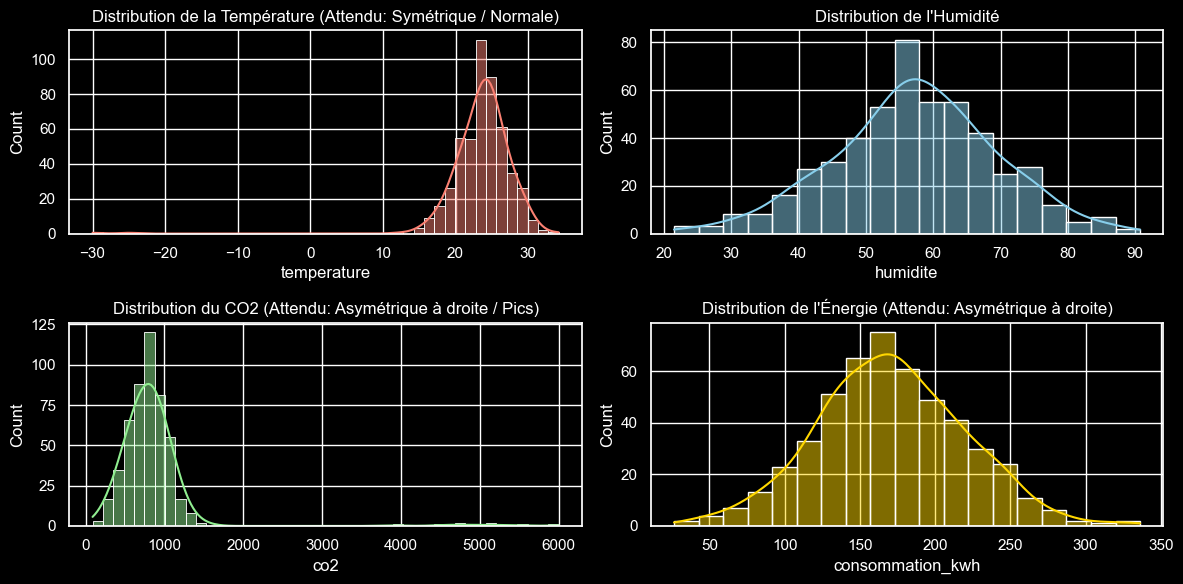

In [340]:
# Identification visuelle des distributions import matplotlib.pyplot as plt

import seaborn as sns

# Configuration du style graphique
sns.set_theme(style="darkgrid")
plt.style.use('dark_background')
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

# 1. Température (Souvent proche d'une distribution normale/symétrique)
sns.histplot(data=df, x='temperature', kde=True, ax=axes[0, 0], color='salmon')
axes[0, 0].set_title('Distribution de la Température (Attendu: Symétrique / Normale)')

# 2. Humidité (Peut être symétrique ou biaisée selon le climat)
sns.histplot(data=df, x='humidite', kde=True, ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title("Distribution de l'Humidité")

# 3. CO2 (Souvent asymétrique à droite : valeurs normales basiques avec des pics de pollution)
sns.histplot(data=df, x='co2', kde=True, ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Distribution du CO2 (Attendu: Asymétrique à droite / Pics)')

# 4. Consommation d'énergie (Souvent asymétrique à droite : consommation de base vs pointes)
sns.histplot(data=df, x='consommation_kwh', kde=True, ax=axes[1, 1], color='gold')
axes[1, 1].set_title("Distribution de l'Énergie (Attendu: Asymétrique à droite)")

plt.tight_layout()
plt.show()



__Note__ : 

b) La dispersion avec violinplot combiné a boxplot

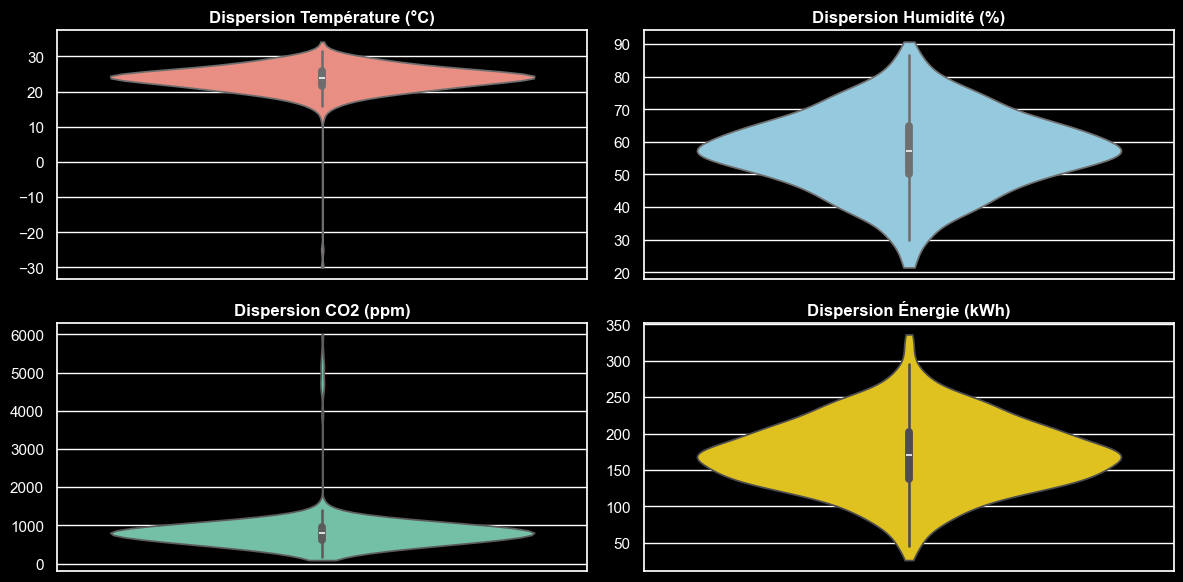

In [341]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.style.use('dark_background')
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

# Liste des variables et des couleurs pour la clarté visuelle
variables = ['temperature', 'humidite', 'co2', 'consommation_kwh']
titles = ['Dispersion Température (°C)', 'Dispersion Humidité (%)', 'Dispersion CO2 (ppm)', 'Dispersion Énergie (kWh)']
colors = ['salmon', 'skyblue', 'mediumaquamarine', 'gold']

# Génération des graphiques
for i, ax in enumerate(axes.flat):
    # On combine un graphique en violon et un boxplot fin à l'intérieur
    sns.violinplot(data=df, y=variables[i], ax=ax, color=colors[i], inner="box", cut=0)
    ax.set_title(titles[i], fontweight='bold')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

c) Les valeurs extrêmes : Le Boxplot (Boîte à moustaches) – Le détecteur standard

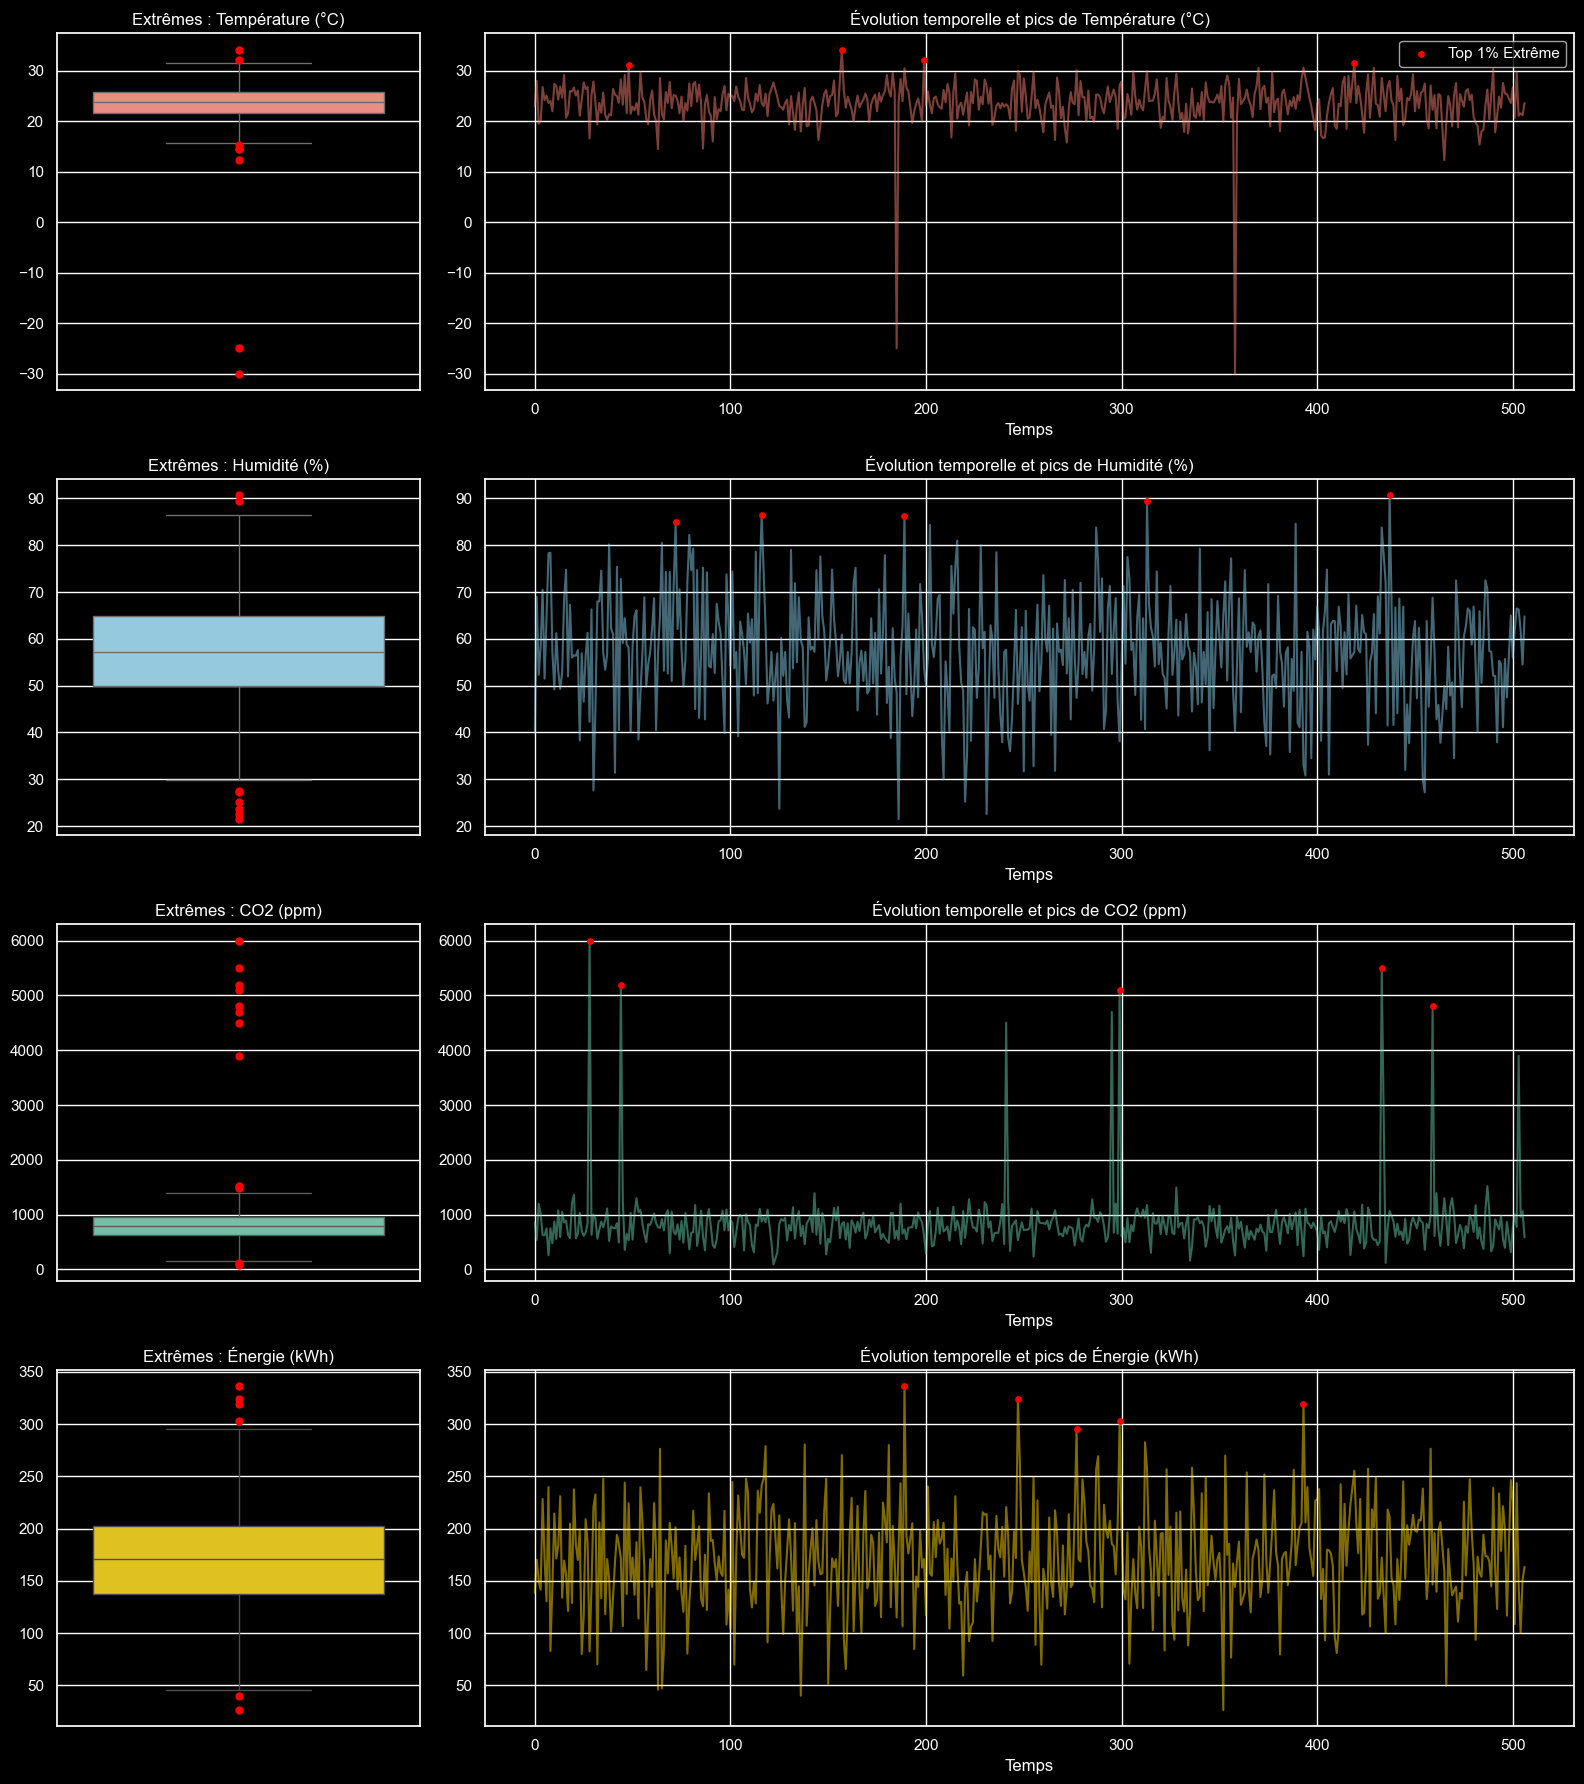

In [342]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.style.use('dark_background')

variables = ['temperature', 'humidite', 'co2', 'consommation_kwh']
colors = ['salmon', 'skyblue', 'mediumaquamarine', 'gold']
labels = ['Température (°C)', 'Humidité (%)', 'CO2 (ppm)', 'Énergie (kWh)']

# Création d'une grille de 4 lignes (une par variable) et 2 colonnes (Boxplot vs Temps)
fig, axes = plt.subplots(4, 2, figsize=(16, 18), gridspec_kw={'width_ratios': [1, 3]})

for i, var in enumerate(variables):
    # --- COLONNE 1 : Le Boxplot pour identifier la quantité d'extrêmes ---
    # flierprops permet de mettre en évidence les points extrêmes en rouge
    sns.boxplot(data=df, y=var, ax=axes[i, 0], color=colors[i], 
                flierprops={"marker": "o", "markerfacecolor": "red", "markeredgecolor": "red", "markersize": 5})
    axes[i, 0].set_title(f"Extrêmes : {labels[i]}")
    axes[i, 0].set_ylabel("")

    # --- COLONNE 2 : Le Scatter Plot pour voir la chronologie des extrêmes ---
    # On trace la ligne générale de l'évolution
    sns.lineplot(data=df, x=df.index, y=var, ax=axes[i, 1], color=colors[i], alpha=0.5)
    
    # Optionnel : On peut surligner les points très hauts en rouge sur la ligne temporelle
    # Ici, on colore en rouge les points au-dessus du 99ème percentile
    seuil_haut = df[var].quantile(0.99)
    extremes = df[df[var] > seuil_haut]
    axes[i, 1].scatter(extremes.index, extremes[var], color='red', s=15, zorder=5, label='Top 1% Extrême')
    
    axes[i, 1].set_title(f"Évolution temporelle et pics de {labels[i]}")
    axes[i, 1].set_ylabel("")
    axes[i, 1].set_xlabel("Temps")
    if i == 0: axes[i, 1].legend()

plt.tight_layout()
plt.show()


d) les valeurs potentiellement aberrantes 

Valeur potentiellement aberrante : Une valeur qui n'a aucun sens ou qui brise les lois de la physique ou de la logique (ex. une humidité à -5%, une température de 85° C dans un bureau, ou une consommation d'énergie qui tombe à exactement 0 en plein après-midi d'usine).

Deux graphiques avancés pour piéger ces anomalies.

Graphique 1 : Scatter plot avec seuils physiques théoriques

On croise la température et l'humidité pour repérer les points qui sortent de la "zone humaine/physique logique".

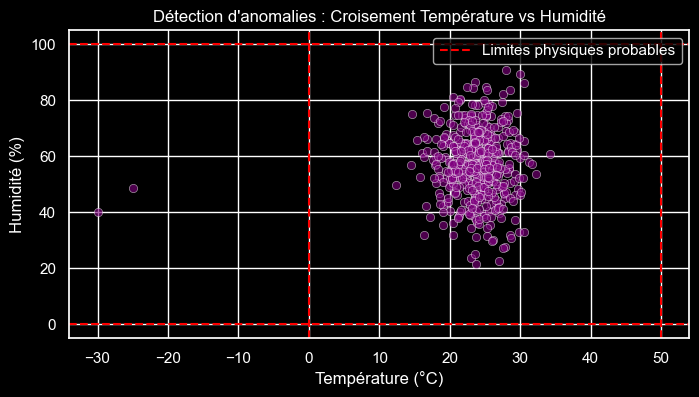

In [343]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
# On trace le nuage de points
sns.scatterplot(data=df, x='temperature', y='humidite', alpha=0.6, color='purple')

# On peut dessiner des lignes rouges pour matérialiser les limites de l'impossible
plt.axvline(x=0, color='red', linestyle='--', label='Limites physiques probables')
plt.axvline(x=50, color='red', linestyle='--')
plt.axhline(y=0, color='red', linestyle='--')
plt.axhline(y=100, color='red', linestyle='--')

plt.title("Détection d'anomalies : Croisement Température vs Humidité")
plt.xlabel("Température (°C)")
plt.ylabel("Humidité (%)")
plt.legend()
plt.show()

Graphique 2 : Le graphique des variations brutales (Sauts de valeurs)

On calcule la différence entre chaque ligne pour voir si le capteur a fait un "bond" impossible.

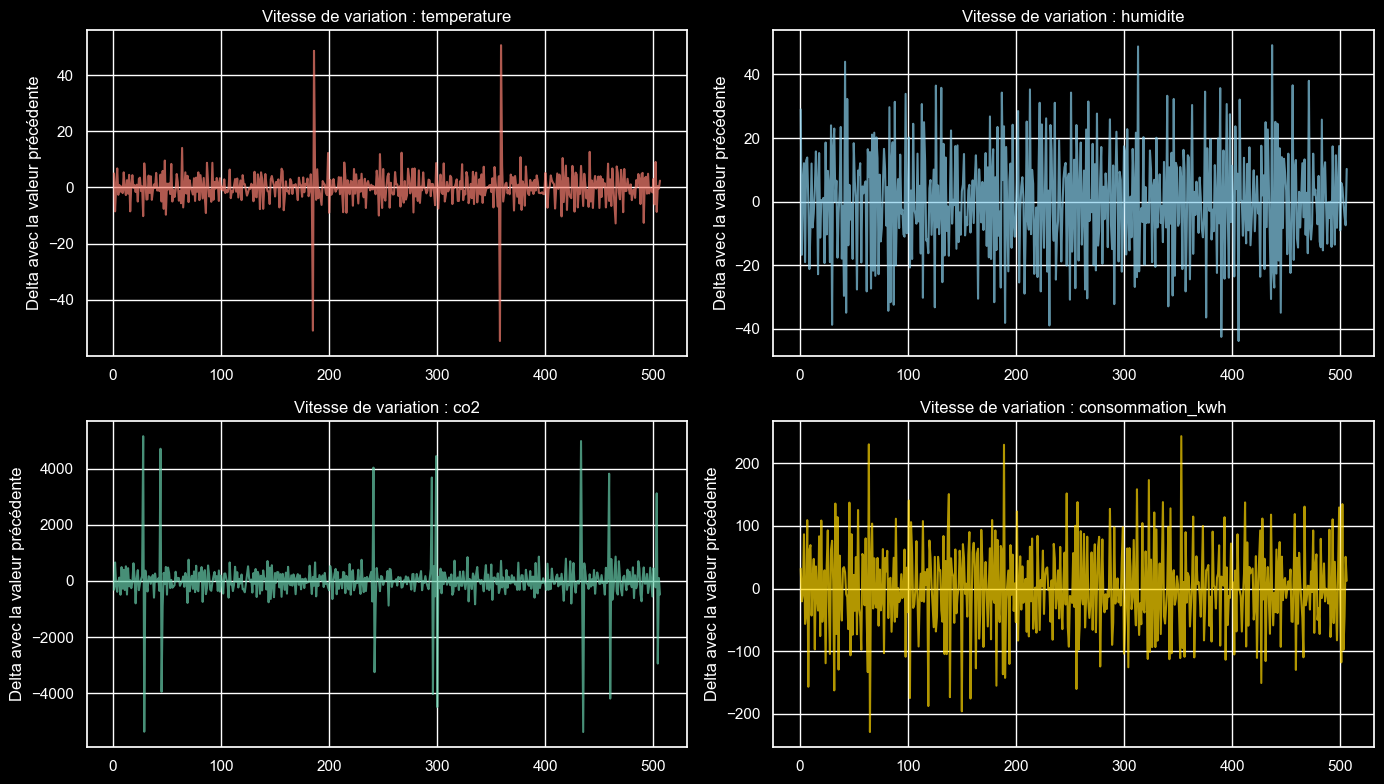

In [344]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
variables = ['temperature', 'humidite', 'co2', 'consommation_kwh']
colors = ['salmon', 'skyblue', 'mediumaquamarine', 'gold']

for i, var in enumerate(variables):
    ax = axes.flat[i]
    # .diff() calcule la variation d'une minute/ligne à l'autre
    variation = df[var].diff()
    
    ax.plot(variation.index, variation, color=colors[i], alpha=0.7)
    ax.set_title(f"Vitesse de variation : {var}")
    ax.set_ylabel("Delta avec la valeur précédente")

plt.tight_layout()
plt.show()

##### <span style="color: #8eb9f6">16) Stratégie utiliser pour les valeurs aberrantes</span>

Stratégie : Le Capping (Le Bornage)

Cette technique consiste à masquer les anomalies en les ramenant de force aux limites acceptables (les "moustaches" de votre boxplot ou un percentile choisi, ex: le 1er et le 99ème percentile).

On utilise le 1er percentile pour la limite basse (on ramène tout ce qui est anormalement bas à cette valeur) et le 99e percentile pour la limite haute (on plafonne tout ce qui est anormalement haut). 
 
 Cela permet de nettoyer les anomalies des deux côtés sans déformer la structure globale de vos données.

In [345]:
import pandas as pd

# Liste des 4 variables
variables = ['temperature', 'humidite', 'co2', 'consommation_kwh']

# Création d'une copie de sauvegarde du DataFrame d'origine
df_clean = df.copy()

# Application du Capping boucle par boucle
for var in variables:
    # Calcul des percentiles 1% (bas) et 99% (haut)
    limite_basse = df[var].quantile(0.01)
    limite_haute = df[var].quantile(0.99)
    
    # Le .clip() va borner automatiquement les valeurs :

    df_clean[var] = df[var].clip(lower=limite_basse, upper=limite_haute)
    
    # Affichage des seuils appliqués pour votre suivi
    print(f"[{var.upper()}] Borné entre : {limite_basse:.2f} et {limite_haute:.2f}")


[TEMPERATURE] Borné entre : 15.39 et 30.60
[HUMIDITE] Borné entre : 27.60 et 84.60
[CO2] Borné entre : 256.84 et 4701.00
[CONSOMMATION_KWH] Borné entre : 51.68 et 282.73


Pourquoi cette méthode dans notre cas ?

Sécurité physique : nos pics extrêmes de \[CO_{2}\] ou de consommation d'énergie ne disparaissent pas de l'analyse, ils sont simplement "lissés" à la valeur maximale historique acceptable du bâtiment (le top 1%). 

Stabilité des modèles : Si on injecte ces données dans un modèle statistique ou de Machine Learning, ce capping supprime l'effet de levier disproportionné que les anomalies avaient sur les calculs.

##### <span style="color: #8eb9f6">17) Affichage des fréquences</span>

a) bâtiments :  diagramme en barres

C:\Users\cissc\AppData\Local\Temp\ipykernel_19008\2387127686.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


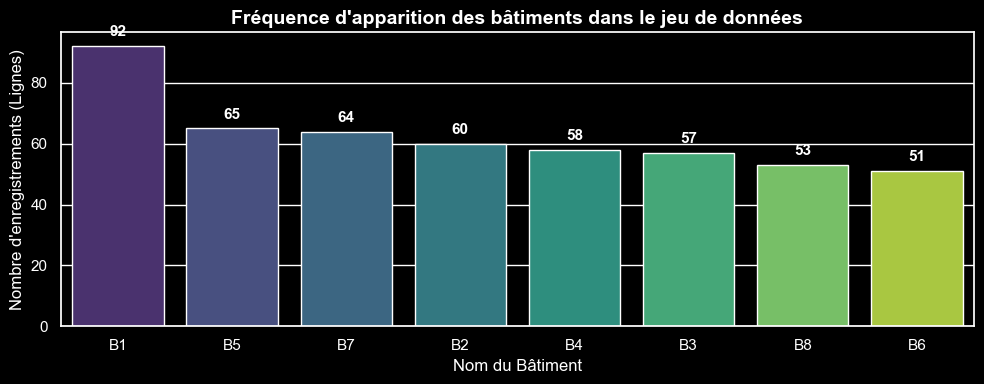

In [346]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration de la taille du graphique
plt.figure(figsize=(10, 4))
#sns.set_theme(style="darkgrid")
plt.style.use('dark_background')


# Création du diagramme de fréquence
# (order permet de trier automatiquement les bâtiments du plus fréquent au moins fréquent)
ax = sns.countplot(
    data=df_clean, 
    x='batiment', 
    order=df_clean['batiment'].value_counts().index, 
    palette='viridis'
)

# Ajout des étiquettes de valeur au-dessus de chaque barre
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}', 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', 
        va='bottom', 
        fontsize=11, 
        fontweight='bold',
        xytext=(0, 5), 
        textcoords='offset points'
    )

# Titres et étiquettes
plt.title("Fréquence d'apparition des bâtiments dans le jeu de données", fontsize=14, fontweight='bold')
plt.xlabel("Nom du Bâtiment", fontsize=12)
plt.ylabel("Nombre d'enregistrements (Lignes)", fontsize=12)

plt.tight_layout()
plt.show()

b) types de bâtiments : Le graphique de fréquence horizontal

C:\Users\cissc\AppData\Local\Temp\ipykernel_19008\1744232642.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


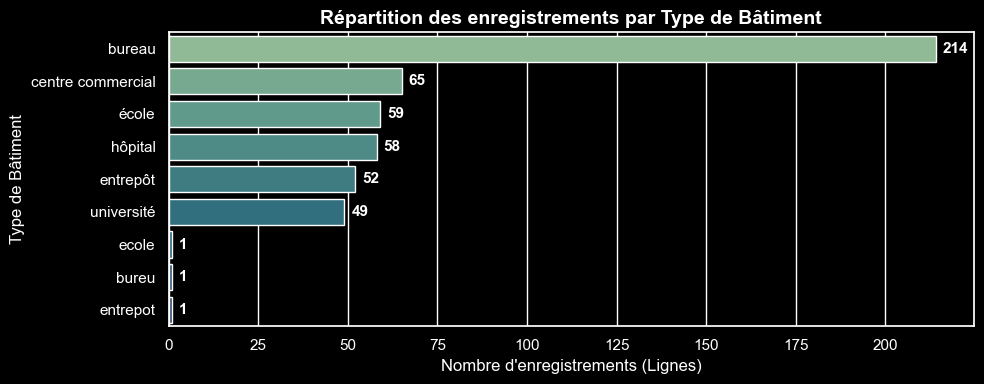

In [347]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 4))
#sns.set_theme(style="darkgrid")
plt.style.use('dark_background')

# Création du graphique de fréquence (trié du plus fréquent au moins fréquent)
ax = sns.countplot(
    data=df_clean, 
    y='type_batiment', 
    order=df_clean['type_batiment'].value_counts().index, 
    palette='crest'
)

# Ajout des valeurs numériques au bout de chaque barre barre
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f'{int(width)}', 
        (width, p.get_y() + p.get_height() / 2.), 
        ha='left', 
        va='center', 
        fontsize=11, 
        fontweight='bold',
        xytext=(5, 0), 
        textcoords='offset points'
    )

# Personnalisation des titres
plt.title("Répartition des enregistrements par Type de Bâtiment", fontsize=14, fontweight='bold')
plt.xlabel("Nombre d'enregistrements (Lignes)", fontsize=12)
plt.ylabel("Type de Bâtiment", fontsize=12)

plt.tight_layout()
plt.show()


c) modes de climatisation : un diagramme en barres vertical

C:\Users\cissc\AppData\Local\Temp\ipykernel_19008\2677977786.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


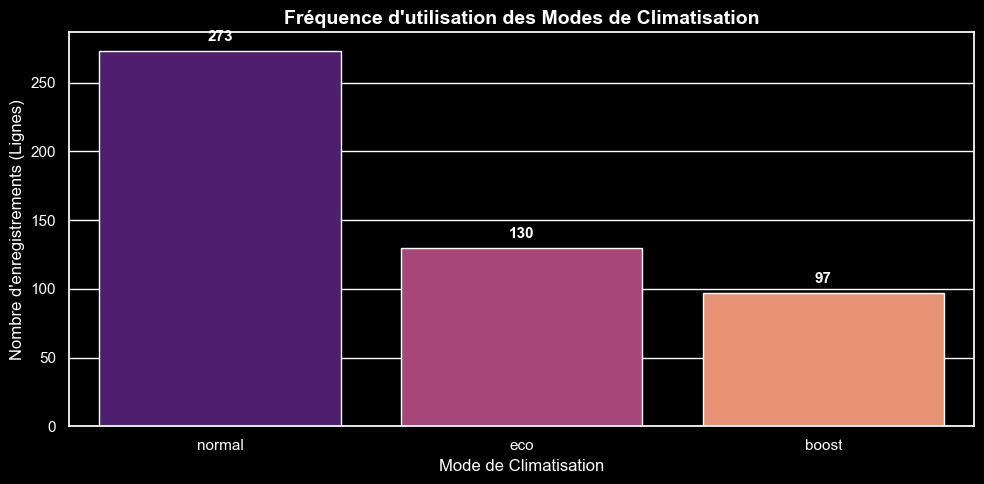

In [353]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuration de la figure
plt.figure(figsize=(10, 5))
#sns.set_theme(style="darkgrid")

# 2. Extraction de l'ordre décroissant pour un affichage propre
ordre_modes = df_clean['mode_climatisation'].value_counts().index

# 3. Génération du graphique de fréquence (Count Plot)
ax = sns.countplot(
    data=df_clean, 
    x='mode_climatisation', 
    order=ordre_modes, 
    palette='magma'
)

# 4. Ajout dynamique des étiquettes de décompte au-dessus de chaque barre
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}', 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', 
        va='bottom', 
        fontsize=11, 
        fontweight='bold',
        xytext=(0, 5), 
        textcoords='offset points'
    )

# 5. Personnalisation des axes et du titre
plt.title("Fréquence d'utilisation des Modes de Climatisation", fontsize=14, fontweight='bold')
plt.xlabel("Mode de Climatisation", fontsize=12)
plt.ylabel("Nombre d'enregistrements (Lignes)", fontsize=12)

plt.tight_layout()
plt.show()


d) états du système :  diagramme en barres vertical

C:\Users\cissc\AppData\Local\Temp\ipykernel_19008\2114394901.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


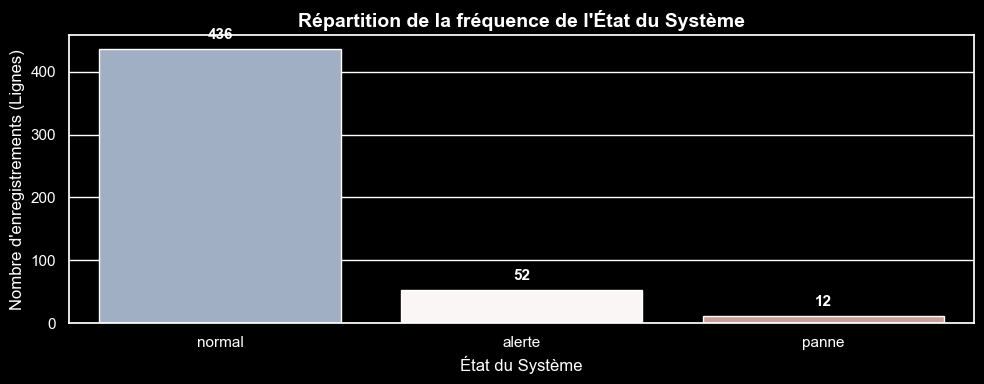

In [359]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuration de la figure
plt.figure(figsize=(10, 4))
sns.set_theme(style="darkgrid")
plt.style.use('dark_background')

# 2. Détermination de l'ordre décroissant pour le tri des barres
ordre_etats = df_clean['etat_systeme'].value_counts().index

# 3. Génération du graphique de fréquence
ax = sns.countplot(
    data=df_clean, 
    x='etat_systeme', 
    order=ordre_etats, 
    palette='vlag'
)

# 4. Ajout des étiquettes numériques au-dessus de chaque barre
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}', 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', 
        va='bottom', 
        fontsize=11, 
        fontweight='bold',
        xytext=(0, 5), 
        textcoords='offset points'
    )

# 5. Habillage du graphique
plt.title("Répartition de la fréquence de l'État du Système", fontsize=14, fontweight='bold')
plt.xlabel("État du Système", fontsize=12)
plt.ylabel("Nombre d'enregistrements (Lignes)", fontsize=12)

plt.tight_layout()
plt.show()


e) classes alerte : un diagramme en barres

C:\Users\cissc\AppData\Local\Temp\ipykernel_19008\3403202854.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


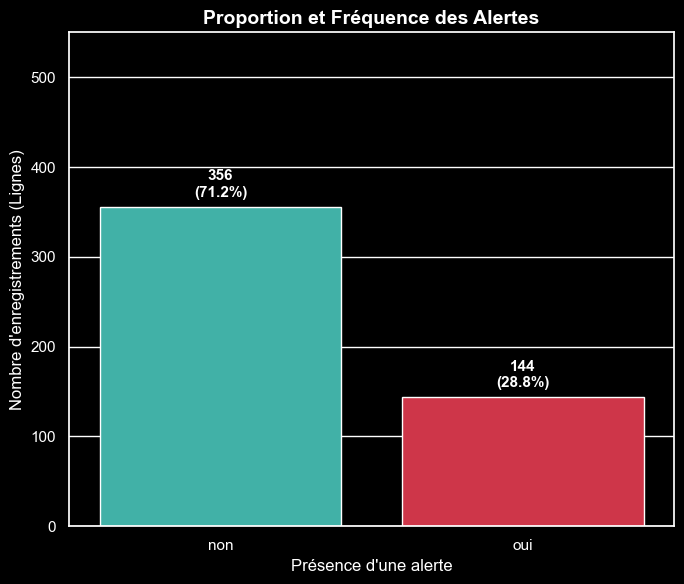

In [367]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuration de la figure
plt.figure(figsize=(7, 6))
#sns.set_theme(style="darkgrid")
plt.style.use('dark_background')

# 2. Définition de l'ordre logique et des couleurs contrastées
# Vert pour 'non' (normal), Rouge pour 'oui' (alerte)
ordre_logique = ['non', 'oui']
couleurs_custom = {'non': '#2ec4b6', 'oui': '#e71d36'}

# 3. Génération du graphique de fréquence (Count Plot)
ax = sns.countplot(
    data=df_clean, 
    x='alerte', 
    order=ordre_logique, 
    palette=couleurs_custom
)

# 4. Ajout des décomptes exacts et des pourcentages au-dessus des barres
total_lignes = len(df_clean)
for p in ax.patches:
    hauteur = p.get_height()
    pourcentage = (hauteur / total_lignes) * 100
    
    ax.annotate(
        f'{int(hauteur)}\n({pourcentage:.1f}%)', 
        (p.get_x() + p.get_width() / 2., hauteur), 
        ha='center', 
        va='bottom', 
        fontsize=11, 
        fontweight='bold',
        xytext=(0, 5), 
        textcoords='offset points'
    )

# 5. Habillage graphique
plt.title("Proportion et Fréquence des Alertes", fontsize=14, fontweight='bold')
plt.xlabel("Présence d'une alerte", fontsize=12)
plt.ylabel("Nombre d'enregistrements (Lignes)", fontsize=12)

# Ajuster les limites verticales pour laisser de la place au texte au-dessus des barres
plt.ylim(0, total_lignes * 1.1)

plt.tight_layout()
plt.show()


##### <span style="color: #8eb9f6">18) Y a-t-il un déséquilibre des classes sur la variable « alerte » ?</span> 

__Note__ : On constate graphiquement que pour la variable _alerte_, la classe 'non' est fortement représenté (71.2 %) contre 28.8 % pour la classe 'oui' donc il y'a un déséquilibre de classes sur cette variable _alerte_

##### <span style="color: #8eb9f6">19) La corrélation sur les variables numériques</span>

a) visualisation avec seaborn, de la matrice de corrélation.

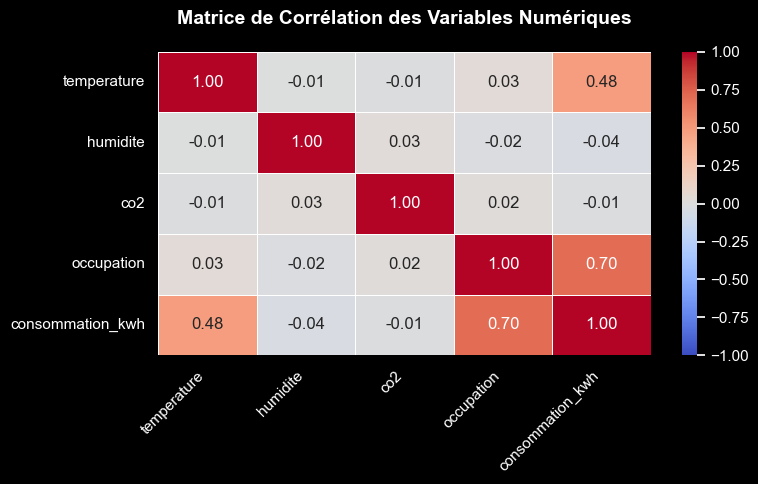

In [370]:
import matplotlib.pyplot as plt
import seaborn as sns

# Liste des variables numériques réelles
variables_num = ['temperature', 'humidite', 'co2', 'occupation', 'consommation_kwh']

# la matrice de corrélation (uniquement sur ces colonnes)
matrice_corr = df_clean[variables_num].corr()


plt.figure(figsize=(8, 5))

# la Heatmap
# 'annot=True' affiche les valeurs chiffrées dans les cases
# 'cmap' définit la palette de couleurs divergente (coolwarm est idéale ici)
# 'vmin=-1, vmax=1' fixe les bornes de l'échelle pour une interprétation rigoureuse
sns.heatmap(
    matrice_corr, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5, 
    vmin=-1, 
    vmax=1
)

#  Habillage du graphique
plt.title("Matrice de Corrélation des Variables Numériques", fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right') # Rotation des labels pour éviter les chevauchements
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


b) identifions les corrélations positives, négatives et les variables faiblement corrélées.

* Le lien entre l'Occupation et le consommation_kwh : On observer un _coefficient positif élevé_ (0.70), confirmant que la présence humaine fait grimper le taux de la consommation. Aussi la variable température est positivement corrélée avec la consommation (0.48)
La variable occupation  pèse le plus lourd sur les dépenses énergétiques.

* Tous les autres coéfficients restent trés faibles ce qui signifie presque une absence de corrélation meme si c'est négatives (des valeurs prochent de 0)



### <span style="color: #0dd7ff">Partie 2 – Séparation X / y </span>

##### <span style="color: #11f3ff">1) Définissons la variable "alerte" comme la cible y</span> 

In [371]:
# 1. Définition de la variable cible (y)
y = df_clean['alerte']

# Vérification rapide de la structure de y
print("Structure de la cible y")
print(f"Format (Shape) : {y.shape}")
print("\nDistribution des classes dans y :")
print(y.value_counts())

Structure de la cible y
Format (Shape) : (500,)

Distribution des classes dans y :
alerte
non    356
oui    144
Name: count, dtype: int64


##### <span style="color: #11f3ff">2) Trouvons les variables explicatives X pertinentes</span> 

Les variables à exclure (Non pertinentes)

* id_mesure : C'est un identifiant unique (clé primaire). Il n'a aucun sens physique ou logique pour prédire une alerte.

* date : Il vaut mieux la retirer ou extraire l'heure, mais on a déjà jour_semaine.

 Les variables à conserver (Pertinentes)
 
 Elles se divisent en deux catégories :

 * Les variables numériques  : temperature, humidite, co2, occupation, consommation_kwh. Elles décrivent l'état physique en temps réel de la pièce.
 
 * Les variables catégorielles (À encoder plus tard) : batiment, type_batiment, zone, mode_climatisation, etat_systeme, jour_semaine. Le contexte (ex: un système en panne ou un type entrepot) est crucial pour expliquer le déclenchement d'une alerte.

In [372]:
variables_X = [
    # Variables numériques
    'temperature', 'humidite', 'co2', 'occupation', 'consommation_kwh',
    # Variables catégorielles (contexte)
    'batiment', 'type_batiment', 'zone', 'mode_climatisation', 'etat_systeme', 'jour_semaine'
]


X = df_clean[variables_X]

# Vérification du résultat
print("Structure de la matrice X")
print(f"Nombre de lignes et de colonnes (Shape) : {X.shape}")
print("\nTypes de données des colonnes sélectionnées :")
print(X.dtypes)


Structure de la matrice X
Nombre de lignes et de colonnes (Shape) : (500, 11)

Types de données des colonnes sélectionnées :
temperature           float64
humidite              float64
co2                   float64
occupation            float64
consommation_kwh      float64
batiment               object
type_batiment          object
zone                   object
mode_climatisation     object
etat_systeme           object
jour_semaine           object
dtype: object


##### <span style="color: #11f3ff">3) Affichage des cinq premières lignes de X ainsi que de y</span>

In [375]:
print("Les 5 premières lignes de la matrice X :")
print(X.head())

Les 5 premières lignes de la matrice X :
   temperature  humidite     co2  occupation  consommation_kwh batiment  \
0         23.0      40.0   851.0        26.0             138.4       b8   
1         28.0      69.0   538.0         0.0             170.2       b7   
2         19.5      52.3  1198.0        64.0             149.8       b5   
3         20.0      58.4  1014.0        30.0             141.6       b6   
4         26.8      70.5   628.0        42.0             228.3       b7   

       type_batiment zone mode_climatisation etat_systeme jour_semaine  
0           entrepot    A                eco       normal        jeudi  
1             bureau    D                eco       normal        lundi  
2  centre commercial    B             normal       normal     dimanche  
3         universite    D             normal       normal     dimanche  
4             bureau    D             normal       normal        jeudi  


In [376]:
print("Les 5 premières lignes de la colonne cible y :")
print(y.head())

Les 5 premières lignes de la colonne cible y :
0    non
1    non
2    oui
3    non
4    non
Name: alerte, dtype: object


### <span style="color: #0dd7ff">Partie 3 – Découpage Train/Test </span>

Divisons X en deux ensembles distincts : un pour l'entraînement (train) et un pour le test (test).

Avec les conditions suivantes : 20% des données serviront au test ; garantir la reproductibilité du 
découpage ; conserver les mêmes proportions de classes dans l'ensemble de train et de test que 
dans les données d'origine. 

In [378]:
from sklearn.model_selection import train_test_split

# Application du découpage Train/Test avec stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

# VÉRIFICATION DES PROPORTIONS
print("Taille des ensembles")
print(f"Ensemble d'entraînement (X_train) : {X_train.shape[0]} lignes")
print(f"Ensemble de test (X_test)         : {X_test.shape[0]} lignes\n")

print("Proportion de la cible 'y' (Stratification)")
print("Proportion dans le dataset d'origine :")
print(y.value_counts(normalize=True) * 100)

print("\nProportion dans l'ensemble d'ENTRAÎNEMENT (y_train) :")
print(y_train.value_counts(normalize=True) * 100)

print("\nProportion dans l'ensemble de TEST (y_test) :")
print(y_test.value_counts(normalize=True) * 100)

Taille des ensembles
Ensemble d'entraînement (X_train) : 400 lignes
Ensemble de test (X_test)         : 100 lignes

Proportion de la cible 'y' (Stratification)
Proportion dans le dataset d'origine :
alerte
non    71.2
oui    28.8
Name: proportion, dtype: float64

Proportion dans l'ensemble d'ENTRAÎNEMENT (y_train) :
alerte
non    71.25
oui    28.75
Name: proportion, dtype: float64

Proportion dans l'ensemble de TEST (y_test) :
alerte
non    71.0
oui    29.0
Name: proportion, dtype: float64


Puisque les alertes sont binaires ('oui'/'non') et déséquilibrées (beaucoup plus de 'non' que de 'oui'), la stratification force _sklearn_ à distribuer équitablement les alertes. 

Sans cela, le hasard aurait pu créer un ensemble de test ne contenant aucun 'oui', rendant l'évaluation du modèle impossible.

### <span style="color: #0dd7ff">Partie 4 – Encodage des variables catégorielles</span> 

Appliquons, en justifiant, l’encodage le plus adapté à chaque variable catégorielle  

Pour éviter les fuites de données (data leakage), on utilisera les encodeurs de scikit-learn ajustés sur l'ensemble d'entraînement (X_train) et appliqués sur l'ensemble de test (X_test).

Choix et Justification de la méthode d'encodage


|Variable | Type de catégorie| Méthode choisie| Justification| 
|:---|:---|:---|:---|
|jour_semaine|Temporel / Cyclique| Encodage Ordinal|Les jours de la semaine ont un ordre naturel (Lundi=0, Mardi=1, ..., Dimanche=6). L'encodage ordinal conserve cette continuité temporelle.|
|batiment|Nominal (sans ordre)|One-Hot Encoding|Le "bâtiment A" n'est pas supérieur ou inférieur au "bâtiment B". Créer des colonnes séparées évite que le modèle n'interprète des faux rapports d'échelle.|
|type_batiment|Nominal (sans ordre)|One-Hot Encoding|Un bureau, une école ou un entrepôt n'ont aucune hiérarchie mathématique entre eux.|
|zone|Nominal (sans ordre)|One-Hot Encoding|La "Zone Nord" et la "Zone Sud" sont des concepts purement géographiques indépendants.|
|mode_climatisation|Nominal (sans ordre)|One-Hot Encoding|Chauffage, Refroidissement ou Éteint sont des états distincts et non ordonnés.|
|etat_systeme|Nominal (sans ordre)|One-Hot Encoding|Actif, Inactif, Maintenance ou Panne décrivent des statuts sans ordre de grandeur numérique implicite.|

In [381]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
import pandas as pd

# Identification des colonnes par type d'encodage
colonnes_one_hot = ['batiment', 'type_batiment', 'zone', 'mode_climatisation', 'etat_systeme']
colonnes_ordinal = ['jour_semaine']

# Définition de l'ordre strict pour la variable ordinale 
# (On s'assure que lundi=0, mardi=1... peu importe l'ordre d'apparition dans le dataset)
ordre_jours = [['lundi', 'mardi', 'mercredi', 'jeudi', 'vendredi', 'samedi', 'dimanche']]

# Création du transformateur de colonnes
# 'remainder="passthrough"' permet de garder les variables numériques (température, CO2, etc.) sans y toucher
preprocesseur = ColumnTransformer(
    transformers=[
        ('one_hot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), colonnes_one_hot),
        ('ordinal', OrdinalEncoder(categories=ordre_jours), colonnes_ordinal)
    ],
    remainder='passthrough'
)

# Ajustement sur le Train et transformation du Train et du Test
# (Note : On récupère les noms de colonnes générés pour reconstruire proprement les DataFrames)
X_train_enc_array = preprocesseur.fit_transform(X_train)
X_test_enc_array = preprocesseur.transform(X_test)

# Reconstruction des DataFrames avec les nouveaux noms de colonnes
noms_colonnes = preprocesseur.get_feature_names_out()

X_train_ready = pd.DataFrame(X_train_enc_array, columns=noms_colonnes, index=X_train.index)
X_test_ready = pd.DataFrame(X_test_enc_array, columns=noms_colonnes, index=X_test.index)

# Vérification visuelle
print("Aperçu de X_train après encodage")
X_train_ready.head(3)

Aperçu de X_train après encodage


,one_hot__batiment_b1,one_hot__batiment_b2,one_hot__batiment_b3,one_hot__batiment_b4,one_hot__batiment_b5,one_hot__batiment_b6,one_hot__batiment_b7,one_hot__batiment_b8,one_hot__type_batiment_bureau,one_hot__type_batiment_centre commercial,...,one_hot__mode_climatisation_normal,one_hot__etat_systeme_alerte,one_hot__etat_systeme_normal,one_hot__etat_systeme_panne,ordinal__jour_semaine,remainder__temperature,remainder__humidite,remainder__co2,remainder__occupation,remainder__consommation_kwh
265,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,5.0,23.1,62.2,952.0,16.0,134.6
110,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,6.0,23.5,59.2,807.0,48.0,142.0
149,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,2.0,26.2,51.1,274.0,69.0,247.7


### <span style="color: #ff0dc7"> Partie 5 – Mise à l'échelle </span>

#### <span style="color: #ff4ed6"> 1) Justification la pertinence de la mise à l’échelle</span> 

 l'importance cruciale de la mise à l'échelle (ou standardisation) dans notre projet, il suffit d'analyser les ordres de grandeur et les unités de trois de nos variables numériques clés : 
 
 * La température : Évolue généralement dans une fourchette étroite, par exemple entre 15°C et 30°C (soit une amplitude d'environ 15 unités). 
 
 * L'occupation : Représente un nombre de personnes, oscillant souvent entre 0 et 50 personnes (amplitude de 50 unités). 
 
 * Le CO_2 : S'exprime en parties par million (ppm) et varie facilement de 400 ppm (air pur) à plus de 1 500 ppm (pièce confinée), soit une amplitude de plus de 1 000 unités.

__Le problème mathématique__ (Sans mise à l'échelle)

La majorité des algorithmes de Machine Learning (comme la Régression Logistique, les K-Plus Proches Voisins ou les Réseaux de Neurones) calculent des distances géométriques ou des poids mathématiques entre les points de données. Si on injecte nos variables brutes dans le modèle : 

* Une variation de 100 ppm de CO_2 sera perçue par l'algorithme comme 10 fois plus importante qu'une variation totale d'occupation (50 personnes) et plus de 6 fois plus grande que toute l'amplitude thermique possible (15°C). 

* Le modèle va accorder toute son attention au CO_2 et à la consommation en kWh, écrasant complètement l'influence de la température et de l'humidité, alors même qu'un problème de température est un facteur majeur pour déclencher une alerte.

#### <span style="color: #ff4ed6"> 2) Application de technique de mise à l'échelle</span> 

TECHNIQUE : Standardiser (Z-score)

La mise à l'échelle va transformer chaque variable pour que sa moyenne soit égale à 0 et son écart-type soit égal à 1. 

La température passera par exemple de [15, 30] à [-1.5, 1.8]. Le CO_2 passera de [400, 1500] à [-1.2, 2.0]. 

Toutes les variables se retrouvent sur la même ligne de départ. Le modèle peut alors analyser l'impact réel de chaque caractéristique sur la variable cible (alerte), sans être biaisé par l'unité de mesure d'origine.

In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Liste des variables numériques d'origine qui ont besoin d'être mises à l'échelle
# (Le préprocesseur précédent leur a ajouté le préfixe 'remainder__' grâce à passthrough)
variables_a_scaler = [
    'remainder__temperature', 
    'remainder__humidite', 
    'remainder__co2', 
    'remainder__occupation', 
    'remainder__consommation_kwh'
]

# 2. Initialisation du StandardScaler
scaler = StandardScaler()

# 3. Création de copies pour accueillir les données finales
X_train_final = X_train_ready.copy()
X_test_final = X_test_ready.copy()

# 4. Ajustement sur le Train et application sur le Train et le Test
# L'ajustement (.fit) se fait UNIQUEMENT sur le Train pour éviter les fuites de données
X_train_final[variables_a_scaler] = scaler.fit_transform(X_train_ready[variables_a_scaler])
X_test_final[variables_a_scaler] = scaler.transform(X_test_ready[variables_a_scaler])

# VÉRIFICATION DU RÉSULTAT
print("Vérification de la mise à l'échelle (Train)")
print(X_train_final[variables_a_scaler].agg(['mean', 'std']).round(2))


--- Vérification de la mise à l'échelle (Train) ---
      remainder__temperature  remainder__humidite  remainder__co2  \
mean                    -0.0                  0.0            -0.0   
std                      1.0                  1.0             1.0   

      remainder__occupation  remainder__consommation_kwh  
mean                    0.0                         -0.0  
std                     1.0                          1.0  


#### <span style="color: #ff4ed6"> 3) Pourquoi ne doit-on pas calculer la moyenne et l'écart-type à partir du dataset complet ?</span> 

On ne doit pas calculer la moyenne et l'écart-type sur le dataset complet pour éviter la fuite de données (data leakage).

* Biais d'évaluation : Si on utilise le dataset complet, l'ensemble de test "contamine" l'ensemble d'entraînement en lui partageant des informations statistiques (sa moyenne et sa variabilité).

* Tricherie involontaire : Le modèle apprend indirectement des caractéristiques de l'ensemble de test, ce qui donne des performances artificiellement gonflées lors de l'évaluation.

* Échec en production : Dans la réalité, les futures données arrivant au coup par coup n'ont pas de moyenne globale connue. Le modèle doit donc être capable de fonctionner en s'appuyant uniquement sur les repères appris lors de l'entraînement.

### <span style="color: #ff0dc7"> Partie 6 – Pipeline de preprocessing</span> 

Contruction d'une pipeline complet avec sklearn

In [383]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier # Exemple de modèle de ML


#  SÉPARATION X / y & TRAIN / TEST

# Définition des listes de variables selon leur type
var_numeriques = ['temperature', 'humidite', 'co2', 'occupation', 'consommation_kwh']
var_categorielles = ['batiment', 'type_batiment', 'zone', 'mode_climatisation', 'etat_systeme', 'jour_semaine']

# Isolation de X et y (la cible 'oui'/'non' est automatiquement gérée par les classifieurs scikit-learn)
X = df_clean[var_numeriques + var_categorielles]
y = df_clean['alerte']

# Découpage stratifié (20% test, reproductible)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 2) PIPELINE DE PREPROCESSING (Les deux branches)

# Branche Gauche : Variables Numériques (Imputation médiane -> StandardScaler)
pipeline_numerique = Pipeline(steps=[
    ('imputation_mediane', SimpleImputer(strategy='median')),
    ('standard_scaler', StandardScaler())
])

# Branche Droite : Variables Catégorielles (Imputation mode -> OneHotEncoder)
pipeline_categoriel = Pipeline(steps=[
    ('imputation_mode', SimpleImputer(strategy='most_frequent')), # 'most_frequent' correspond à la mode
    ('one_hot_encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Concaténation des deux branches (ColumnTransformer) -> Donne le "Dataset préparé"
preprocesseur = ColumnTransformer(transformers=[
    ('branche_num', pipeline_numerique, var_numeriques),
    ('branche_cat', pipeline_categoriel, var_categorielles)
])


# 3) PIPELINE GLOBAL (Preprocessing + Modèle)

# On assemble le préprocesseur et le modèle final dans un seul et même objet
pipeline_final = Pipeline(steps=[
    ('preprocessing', preprocesseur),
    ('modele_ml', RandomForestClassifier(random_state=42)) # Remplaçable par n'importe quel modèle de classification
])


# 4) ENTRAÎNEMENT ET PRÉDICTION

# Le pipeline applique automatiquement le bon traitement à chaque colonne et entraîne le modèle
pipeline_final.fit(X_train, y_train)

# Évaluation rapide du score sur l'ensemble de test
score_test = pipeline_final.score(X_test, y_test)
print(f"Pipeline entraîné avec succès ! Précision globale (Accuracy) sur le Test : {score_test:.2%}")


Pipeline entraîné avec succès ! Précision globale (Accuracy) sur le Test : 91.00%


Pourquoi cette structure est redoutablement efficace :

* Zéro risque de fuite (Data Leakage) : Le SimpleImputer calcule la médiane et la mode uniquement sur le X_train. Si des valeurs sont manquantes dans le X_test ou dans de futures données réelles, il utilisera ces repères fixes sans tricher.

* Un bloc unique industrialisable : Pour prédire une alerte sur une nouvelle mesure brute arrivant en production, il vous suffit de faire pipeline_final.predict(nouvelles_donnees). Le nettoyage, le capping (si intégré), l'imputation, l'encodage et la prédiction se font en une seule micro-seconde.

### <span style="color: #ff0dc7"> Partie 7 : Exportation</span>  

Exportation du dataframe nettoyé dans exports/smart_building_cleaned.csv 

In [384]:
# Exportation directe dans le dossier existant
df_clean.to_csv('../exports/smart_building_cleaned.csv', index=False, encoding='utf-8')

print("Le fichier 'smart_building_cleaned.csv' a été enregistré avec succès dans le dossier '../exports/'.")

Le fichier 'smart_building_cleaned.csv' a été enregistré avec succès dans le dossier '../exports/'.
